<a href="https://colab.research.google.com/github/msiplab/EicEngLabIV/blob/master/example02_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 実験Ⅳ－２　時系列データのARモデル構築

1. サンプルデータの読み込み（訓練データとテストデータへの分割）
1. 原系列 $y_n$ の偏自己相関関数(PARCOR)のコレログラムとADF検定
1. 階差系列 $\Delta y_n=y_n-y_{n-1}$ の偏自己相関関数(PARCOR)のコレログラムとADF検定
1. ARモデルの係数パラメータ推定（訓練データ）
1. カルマンフィルタ（ARモデル）による時系列の推定（訓練データ）と予測（テストデータ）

参考図書

- 時系列解析入門／北川源四郎／岩波書店
- 時系列解析／島田直希／共立出版
- 時系列解析入門〔第２版〕／宮野尚哉・後藤田浩／サイエンス社

新潟大学工学部工学科　電子情報通信プログラム 

## 準備

In [1]:
!pip install pykalman
!pip install japanize-matplotlib
%matplotlib inline

import warnings
warnings.simplefilter('ignore') #警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib #日本語化matplotlib
sns.set(font="IPAexGothic") #日本語フォント設定

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 5.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 38.0 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=9e750a3934f7d3e5b062988400459bac58c0cf7b0c0384586d328c9a48c2006d
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


## サンプルデータの読み込み

OCCTO 広域予備率Web公表システムから東北エリアの需給実績（エリア需要）を取得する。

In [2]:
strtitle = '東北エリア需給実績（OCCTO）'
maxlag = 50 # 30分刻みデータの最大ラグ

from urllib.request import urlopen
from urllib.parse import urlencode
import io

base_url = 'https://web-kohyo.occto.or.jp/kks-web-public/download/downloadCsv'
params = {
    'jhSybt': '02',  # 広域予備率ブロック情報(翌日・当日)
    'tgtYmdFrom': '2025/07/01',
    'tgtYmdTo': '2025/07/31',
}
url = base_url + '?' + urlencode(params)

with urlopen(url) as f:
    raw = f.read()

df_raw = pd.read_csv(io.BytesIO(raw), encoding='utf-8-sig', skiprows=1)
df_area = df_raw[df_raw['エリア名'] == '東北'].copy()

df_area['t'] = pd.to_datetime(df_area['対象年月日'] + ' ' + df_area['時刻'], errors='coerce')
# "24:00" は翌日 00:00 として扱う
mask_24 = df_area['時刻'] == '24:00'
df_area.loc[mask_24, 't'] = pd.to_datetime(df_area.loc[mask_24, '対象年月日']) + pd.Timedelta(days=1)
df_area['y'] = df_area['エリア需要(MW)'].astype(float)

df_full = df_area[['t', 'y']].dropna().sort_values('t').reset_index(drop=True)
display(df_full.head())
print(f'取得件数: {len(df_full)}')

,t,y
0,2025-07-01 00:30:00,7575.032
1,2025-07-01 01:00:00,7241.312
2,2025-07-01 01:30:00,7248.332
3,2025-07-01 02:00:00,7151.712
4,2025-07-01 02:30:00,7203.526


取得件数: 1488


## 時系列データをpandas.DataFrameオブジェクトに変換

pandas ライブラリの DataFrame オブジェクトに変換

- t: 時刻
- y: データの値

以下では取得期間全体のデータで分析を進める。
訓練データ（推測用）とテストデータ（予測用）の割合を testdataratio で設定する。

- 訓練データ：テストデータ = (1-testdataratio) : testdataratio

In [3]:
# テスト期間（後半）の割合
testdataratio = 0.5

# 解析期間の設定（取得データの全期間）
dts00 = df_full['t'].min()
dte00 = df_full['t'].max()

df_timeseries = df_full[(df_full.t>=dts00) & (df_full.t<=dte00)].copy()
df_timeseries = df_timeseries.reset_index(drop=True)
display(df_timeseries)
ntest = int(np.ceil(testdataratio*len(df_timeseries)))
ntrain = len(df_timeseries) - ntest
print('#訓練データ（前部） : #テストデータ（後部） = {0:d} : {1:d}'.format(ntrain,ntest))

,t,y
0,2025-07-01 00:30:00,7575.032
1,2025-07-01 01:00:00,7241.312
2,2025-07-01 01:30:00,7248.332
3,2025-07-01 02:00:00,7151.712
4,2025-07-01 02:30:00,7203.526
...,...,...
1483,2025-07-31 22:00:00,9669.432
1484,2025-07-31 22:30:00,9416.720
1485,2025-07-31 23:00:00,9123.250
1486,2025-07-31 23:30:00,8789.234


#訓練データ（前部） : #テストデータ（後部） = 744 : 744


## 欠損データの補間

データの欠損箇所があるため，前のデータで補間する。pandas.Series の以下のメソッドを利用できる。

- fillna(method='ffill')

In [4]:
df_timeseries['y_fillna'] = df_timeseries['y'].fillna(method='ffill').astype(float) 
display(df_timeseries)

,t,y,y_fillna
0,2025-07-01 00:30:00,7575.032,7575.032
1,2025-07-01 01:00:00,7241.312,7241.312
2,2025-07-01 01:30:00,7248.332,7248.332
3,2025-07-01 02:00:00,7151.712,7151.712
4,2025-07-01 02:30:00,7203.526,7203.526
...,...,...,...
1483,2025-07-31 22:00:00,9669.432,9669.432
1484,2025-07-31 22:30:00,9416.720,9416.720
1485,2025-07-31 23:00:00,9123.250,9123.250
1486,2025-07-31 23:30:00,8789.234,8789.234


## 原系列 $y_n$ のプロット


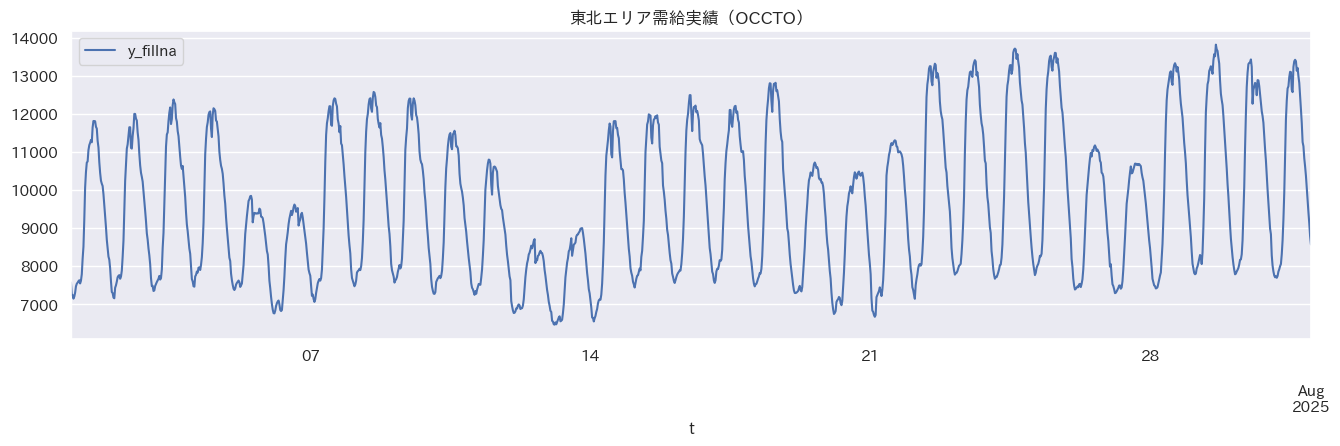

In [5]:
ax = df_timeseries.plot(x='t', y='y_fillna', figsize=(16,4), title=strtitle)


## 原系列 $y_n$ の自己相関関数

原系列 $y_n$ の時間依存性を確かめるために，自己相関関数のコレログラムを描画する。
自己相関関数のコレログラム描画にはstatsmodelsライブラリを利用できる。

- acf()
- plot_acf()

なお，コレログラム中の青色の帯は 95%信頼区間で，帯の外側の値を有意とみなす。


744

y_acf:
[ 1.          0.98480519  0.9514606   0.90451873  0.84643209  0.77876342
  0.70400706  0.62476343  0.54291622  0.45909229  0.37146151  0.27959199
  0.18478279  0.08900459 -0.00501123 -0.0952126  -0.1795721  -0.25607958
 -0.32317478 -0.38066165 -0.42847671 -0.46656651 -0.49436741 -0.51069892
 -0.51621947 -0.51116481 -0.49513149 -0.46765109 -0.43040013]


Text(0.5, 0, 'lag')

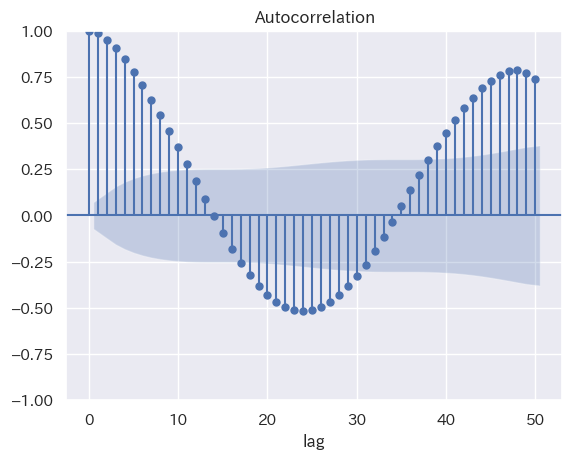

In [6]:
import statsmodels.api as sm
from statsmodels.tsa import stattools

y_series = df_timeseries['y_fillna'][:ntrain] # 訓練データ
display(len(y_series))
y_acf = sm.tsa.stattools.acf(y_series)
print('y_acf:')
print(y_acf)
fig = sm.graphics.tsa.plot_acf(y_series, lags=maxlag)
fig.axes[0].set_xlabel('lag')




## 原系列 $y_n$ の偏自己相関関数(PARCOR)

原系列 $y_n$ の時間依存性を確かめるために，偏自己相関関数(PARCOR)のコレログラムを描画する。
偏自己相関関数のコレログラム描画にはstatsmodelsライブラリを利用できる。

- pacf()
- plot_pacf()

y_pacf:
[ 1.          0.98613063 -0.66899689 -0.14997414 -0.1313401  -0.1199843
 -0.02139424  0.00247825 -0.02130101 -0.08415774 -0.24848851 -0.16517248
 -0.06944963 -0.00923679  0.09247382  0.05381155  0.03677295  0.01783969
 -0.00901185 -0.03675757  0.02418244  0.05646973  0.11438926  0.15461217
  0.0011605   0.01135809  0.03283348  0.05715644 -0.03154707]


Text(0.5, 0, 'lag')

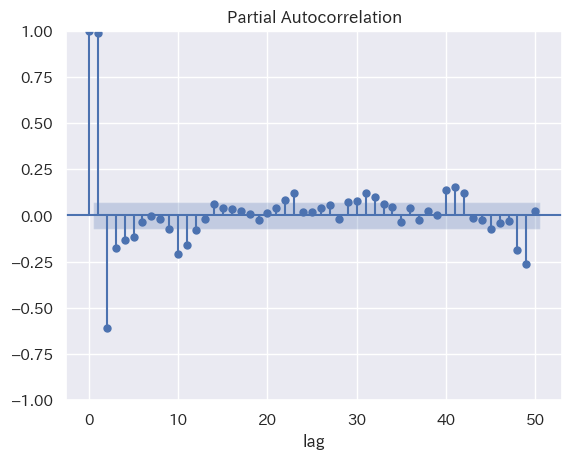

In [7]:
y_pacf = sm.tsa.stattools.pacf(y_series)
print('y_pacf:')
print(y_pacf)
fig = sm.graphics.tsa.plot_pacf(y_series, lags=maxlag)
fig.axes[0].set_xlabel('lag')


## 原系列 $y_n$ の定常性の検証

PARCORのコレログラムから24時間間隔での有意な偏相関がみられる。絶対値は1以下なので単位根過程か否かを検証する。

原系列 $y_n$ が定常過程であるかを確認するため，ADF(augmented Dickey-Fuler)検定を実施する。


ADF検定では，
- 帰無仮説 $H_0: \rho=1$（単位根過程）
- 対立仮説 $H_1: 0<\rho <1$ （弱定常過程）

として検定を行う。

帰無仮説が正しいにも関わらず，帰無仮説を棄却する誤りの確率をp値(p-value)という。このp値がある有意水準（significant level）より小さければ，帰無仮説を棄却し，対立仮説を受容する。すなわち，ADF検定のp値が高いと単位根過程であるという仮説を棄却できない（定常過程であるといえない）。





In [8]:
y_adftest = stattools.adfuller(y_series)
print('y_adftest:')
print(y_adftest)

y_adftest:
(np.float64(-7.393390724803605), np.float64(7.892630436246464e-11), 13, 730, {'1%': np.float64(-3.4393396487377155), '5%': np.float64(-2.865507363200066), '10%': np.float64(-2.5688826684180897)}, np.float64(9448.373832487041))


## 階差系列 $\Delta y_n$ のプロット

ADF検定結果の2番目の値がp値。原系列 $y_n$ のADF検定の結果，p値が有意水準0.05 よりも大きいため単位根過程という仮説を棄却できない。

そこで，階差系列

$\Delta y_n=y_n-y_{n-1}$
    
の分析を進める。





,t,y,y_fillna,y_fillna_diff
0,2025-07-01 00:30:00,7575.032,7575.032,NaN
1,2025-07-01 01:00:00,7241.312,7241.312,-333.720
2,2025-07-01 01:30:00,7248.332,7248.332,7.020
3,2025-07-01 02:00:00,7151.712,7151.712,-96.620
4,2025-07-01 02:30:00,7203.526,7203.526,51.814
...,...,...,...,...
1483,2025-07-31 22:00:00,9669.432,9669.432,-370.794
1484,2025-07-31 22:30:00,9416.720,9416.720,-252.712
1485,2025-07-31 23:00:00,9123.250,9123.250,-293.470
1486,2025-07-31 23:30:00,8789.234,8789.234,-334.016


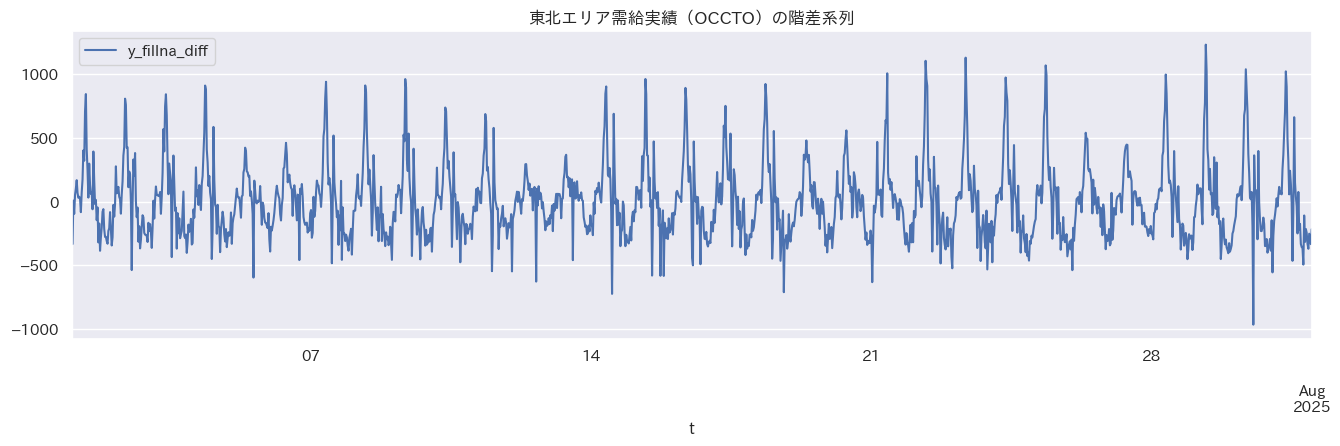

In [9]:
df_timeseries['y_fillna_diff'] = df_timeseries['y_fillna'].diff()
display(df_timeseries)
ax = df_timeseries.plot(x='t', y='y_fillna_diff', figsize=(16,4), title=strtitle+'の階差系列')

## 階差系列 $\Delta y_n$ の自己相関関数

階差系列 $\Delta y_n$ の時間依存性を確かめるために，自己相関関数のコレログラムを描画する。

先頭の値のみ非数(nan)であるため，dropna() で削除する．




,y_fillna_diff
1,-333.720
2,7.020
3,-96.620
4,51.814
5,103.208
...,...
739,283.778
740,154.182
741,275.032
742,213.934


y_fillna_diff_acf:
[ 1.          0.7350623   0.57141925  0.47113743  0.40419759  0.31115625
  0.22331401  0.15724941  0.13593256  0.19239596  0.1986562   0.13507582
  0.05230146 -0.06733197 -0.14208956 -0.22830199 -0.29816452 -0.35662467
 -0.37696979 -0.38518248 -0.40172548 -0.41965544 -0.47228204 -0.45780704
 -0.43752975 -0.46419233 -0.47177482 -0.41080591 -0.38988242]


Text(0.5, 0, 'lag')

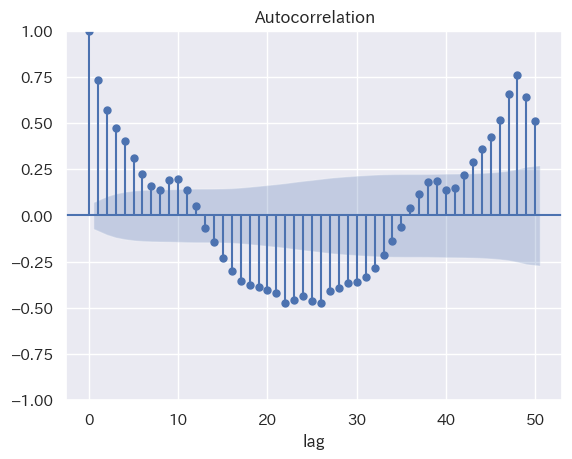

In [10]:
y_diff_series = df_timeseries['y_fillna_diff'][:ntrain].dropna()
display(y_diff_series)
y_fillna_diff_acf = sm.tsa.stattools.acf(y_diff_series)
print('y_fillna_diff_acf:')
print(y_fillna_diff_acf)
fig = sm.graphics.tsa.plot_acf(y_diff_series, lags=maxlag)
fig.axes[0].set_xlabel('lag')

## 階差系列 $\Delta y_n$ の偏自己相関関数(PARCOR)

階差系列 $\Delta y_n$ の時間依存性を確かめるために，偏自己相関関数(PARCOR)のコレログラムを描画する。

y_fillna_diff_pacf:
[ 1.          0.73605295  0.06806159  0.06560815  0.04955737 -0.06058404
 -0.04652271 -0.02107755  0.04884905  0.18700532  0.00897175 -0.11915865
 -0.13333479 -0.23858068 -0.08281598 -0.1065518  -0.04311518 -0.03719108
 -0.05606618 -0.10565805 -0.14449673 -0.1375363  -0.17584185  0.03152595
  0.02705418 -0.09991611 -0.07774379  0.01872348 -0.1694554 ]


Text(0.5, 0, 'lag')

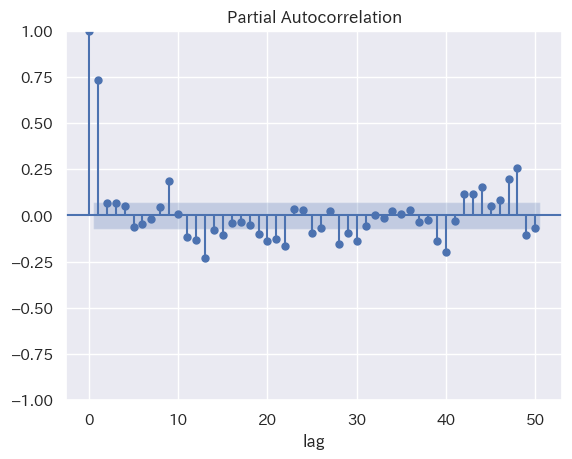

In [11]:
y_fillna_diff_pacf = sm.tsa.stattools.pacf(y_diff_series)
print('y_fillna_diff_pacf:')
print(y_fillna_diff_pacf)
fig = sm.graphics.tsa.plot_pacf(y_diff_series, lags=maxlag)
fig.axes[0].set_xlabel('lag')

## 階差系列 $\Delta y_n$ の定常性の検証

PARCORのコレログラムから24時間間隔での有意な偏相関がみられる。絶対値は1以下なので単位根過程か否かを検証する。定常性の検証にADF検定を実施する。

In [12]:
y_diff_adftest = stattools.adfuller(y_diff_series)
print('y_diff_adftest:')
print(y_diff_adftest)

y_diff_adftest:
(np.float64(-10.996797935597455), np.float64(6.838929540688223e-20), 20, 722, {'1%': np.float64(-3.439439614524914), '5%': np.float64(-2.865551414233055), '10%': np.float64(-2.5689061365397747)}, np.float64(9442.16963017154))


## 階差系列 $\Delta y_n$ のARモデルの構築

ADF検定結果の2番目の値がp値。階差系列 $\Delta y_n$ のADF検定の結果，p値が有意水準0.05 よりも小さいため単位根過程という仮説を棄却する。結果として定常過程であることを確認できたため階差系列 $\Delta y_n$ のARモデルを構築する。

ARモデルの構築に statsmodels ライブラリの ar_model モジュールを利用する。

なお、デフォルトでは定数 $a_0$ を考慮したモデル

$v_n = a_0 + \sum_{k=1}^{p}a_k v_{n-k}+w_n$, $w_n\sim N(0,\sigma^2)$

が採用される。

statsmodels の ar_model.ar_select_order では、引数 ic に 'aic' を指定すると、 maxlag までの次数の中で最小AIC法により次数pの選択がなされる。

In [13]:
from statsmodels.tsa import ar_model
# ARモデルのインスタンス生成
arpmodel = ar_model.ar_select_order(y_diff_series,maxlag,ic='aic')
# ARモデルの最適次数推定
ords = arpmodel.ar_lags
popt = max(ords)
print('popt = {:2d}'.format(popt))

popt = 48


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


## ARモデルの評価

残差とそのPARCORの表示


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Text(0.5, 0, 'lag')

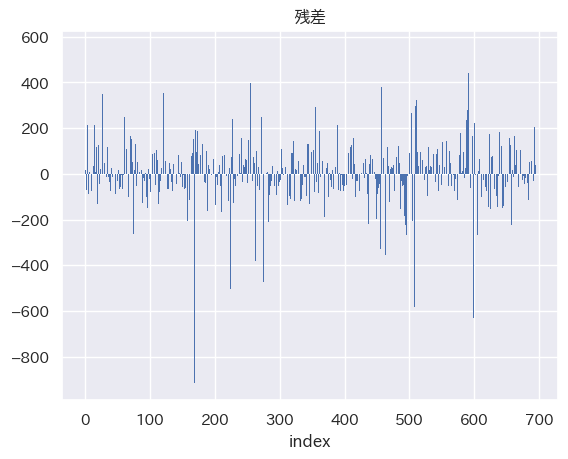

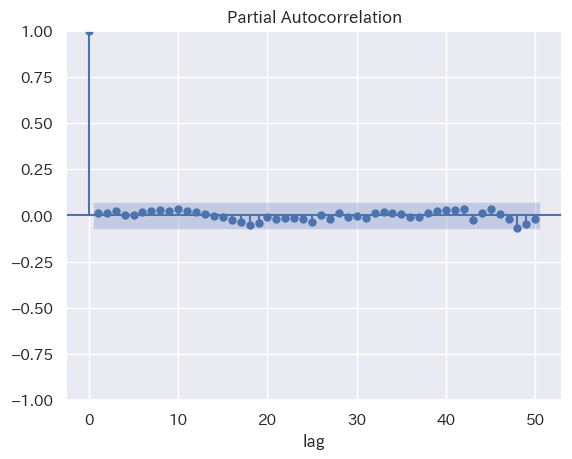

In [14]:
# ARモデルの係数パラメータ推定
results = ar_model.AutoReg(y_diff_series,ords).fit()
residual = results.resid
# 残差のプロット
fig, ax = plt.subplots()
bc = plt.bar(range(len(residual)), residual, edgecolor='none')
ax.set_title('残差')
ax.set_xlabel('index')
# 残差のPARCOR
fig = sm.graphics.tsa.plot_pacf(residual, lags=maxlag)
fig.axes[0].set_xlabel('lag')



## ARモデルによる推定と予測結果

- 実線：階差系列 $\Delta y_n$
- 破線：ARモデルによる推定と予測 



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


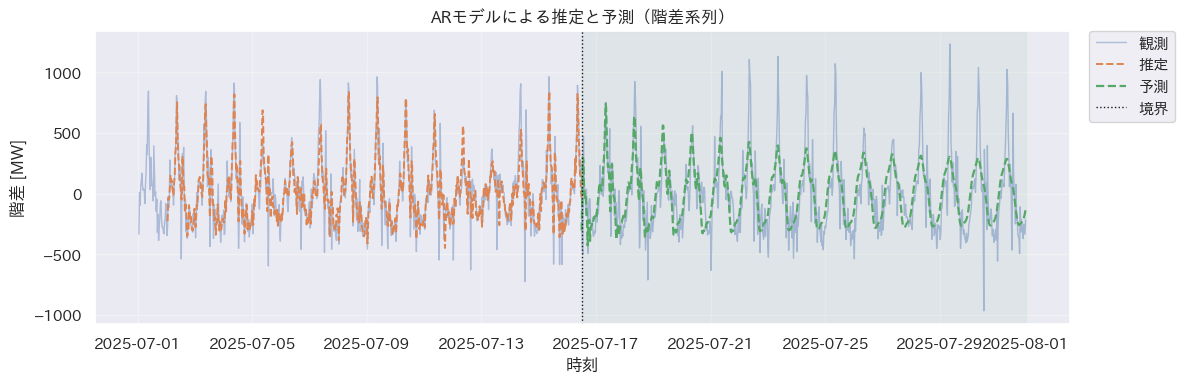

In [22]:
# 階差系列 （訓練データ区間＋テストデータ区間）
y_diff_orig = df_timeseries['y_fillna_diff'].dropna()
t_diff_all = df_timeseries.loc[y_diff_orig.index, 't']

fit_vals = results.fittedvalues
t_fit = df_timeseries.loc[fit_vals.index, 't']

pred_vals = results.predict(ntrain - 1, ntrain + ntest - 1, dynamic=True)
t_pred = df_timeseries.loc[pred_vals.index, 't']

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title('ARモデルによる推定と予測（階差系列）')
ax.set_xlabel('時刻')
ax.set_ylabel('階差 [MW]')
ax.plot(t_diff_all, y_diff_orig, label='観測', color='C0', alpha=0.4, linewidth=1.0)
ax.plot(t_fit, fit_vals, '--', label='推定', color='C1', linewidth=1.4)
ax.plot(t_pred, pred_vals, '--', label='予測', color='C2', linewidth=1.6)

t_split = df_timeseries['t'].iloc[ntrain - 1]
ax.axvline(t_split, color='k', linestyle=':', linewidth=1.0, label='境界')
ax.axvspan(df_timeseries['t'].iloc[ntrain], df_timeseries['t'].iloc[-1], color='C2', alpha=0.08)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
ax.grid(True, alpha=0.3)
plt.tight_layout()

## カルマンフィルタとしてのARモデル

定数 $a_0$ を考慮したモデル。

- 状態ベクトル
$\boldsymbol{x}_{n}=\left(\begin{array}{lllll}
v_{n} & \left(a_{2} v_{n-1}+\cdots+a_{p} v_{n-p+1}\right) & \cdots & \left(a_{p-1} v_{n-1}+a_{p} v_{n-2}\right) & a_{p} v_{n-1} & a_0
\end{array}\right)^{T}$
- 推移行列
$\boldsymbol{F}_{n}=\left(\begin{array}{cccccc}
a_{1} & 1 & \cdots & 0 & 0 & 0 \\
a_{2} & 0 & \ddots & 0 & 0 & 0  \\
\vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
a_{p-1} & 0 & \cdots & 0 & 1 & 0\\
a_{p} & 0 & \cdots & 0 & 0 & 0\\
0 & 0 & \cdots & 0 & 0  & 1
\end{array}\right)$
- 係数行列
$\boldsymbol{G}_{n}=\left(\begin{array}{c}
1 \\
0 \\
\vdots \\
0 \\
0 
\end{array}\right)$,
- 観測行列
$\boldsymbol{H}_{n}=\left(\begin{array}{cccccc}
1 & 0 & \cdots & 0 & 0 & 1
\end{array}\right)$,
- システムノイズの分散
$\boldsymbol{Q}_{n}=\sigma^{2}$, 
- 観測ノイズの分散
$\boldsymbol{R}_{n}=0$

上記は系列 $v_n$ を対象とした標記のため階差系列 $\Delta y_n$ に適用する際には　$v_n$ を $\Delta y_n$ と読替える。


In [16]:
n_dim_state = popt+1
ar_const = results.params[0]
ar_coefs = results.params[1:].to_numpy()

# 推移行列
f1 = ar_coefs.reshape(-1,1)
f2 = np.eye(popt)
f2[-1,-1] = 0.
f3 = np.zeros((1,n_dim_state))
f3[-1,-1] = 1.
F = np.block([ [f1, f2], [f3] ])
print('F = ')
print(F)

# 係数行列
G = np.zeros((n_dim_state,1))
G[0,0] = 1.
print('G = ')
print(G)

# 観測行列
H = np.zeros((1,n_dim_state))
H[0,0] = 1.
H[-1,-1] = 1.
print('H = ')
print(H)

# システムノイズの分散
Q = results.sigma2
print('Q = ')
print(Q)

# 観測ノイズの分散
R = 0.

F = 
[[ 0.25462625  1.          0.         ...  0.          0.
   0.        ]
 [-0.00677088  0.          1.         ...  0.          0.
   0.        ]
 [ 0.04718321  0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.10760704  0.          0.         ...  0.          1.
   0.        ]
 [ 0.35044201  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   1.        ]]
G = 
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]
H = 
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  1.]]
Q = 
16732.981810578345


## カルマンフィルタオブジェクト生成

pykalman ライブラリを使用

インストール方法は以下の通り

\$ pip install pykalman

In [17]:
from pykalman import KalmanFilter

# 観測値の次元数
n_dim_obs = 1
# 状態の平均ベクトルの初期値
initial_state_mean = ar_const*np.ones(n_dim_state)
# 状態の分散共分散行列の初期値
initial_state_covariance = np.eye(n_dim_state)

# カルマンフィルタによるARモデル生成
kf = KalmanFilter(
        n_dim_obs=n_dim_obs,
        n_dim_state=n_dim_state,
        initial_state_mean=initial_state_mean,
        initial_state_covariance=initial_state_covariance,
        transition_matrices=F,
        observation_matrices=H,
        observation_covariance=R,
        transition_covariance=G.dot(Q).dot(G.T)
)


## カルマンフィルタ（ARモデル）による推定と予測結果

- 実線：階差系列 $\Delta y_n$
- 破線：ARモデルによる推定と予測 

観測結果を予測に反映するため推定精度が向上する。

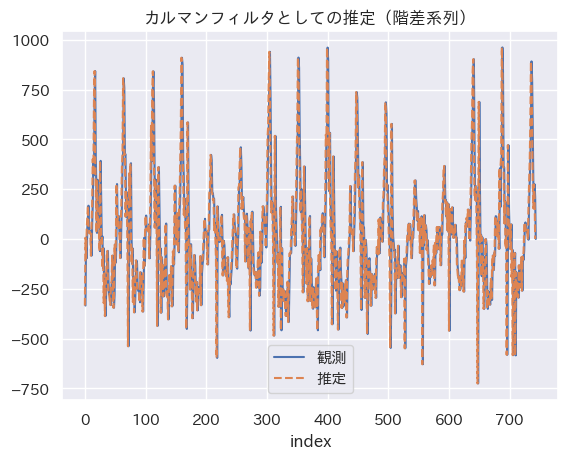

In [23]:
# 訓練データ
y_diff_train = df_timeseries['y_fillna_diff'][:ntrain].dropna()

# フィルタ
filtered_state_means, filtered_state_covs = kf.filter(y_diff_train)
# 訓練データの推定値
y_diff_filtered_pred = filtered_state_means.dot(H.T)

# プロット
fig, ax = plt.subplots()
ax.set_title('カルマンフィルタとしての推定（階差系列）')
ax.set_xlabel('index')
# ARモデルの予測（訓練データ区間）
plt.plot(y_diff_train, label='観測')
plt.plot(y_diff_filtered_pred, '--', label='推定')
# 凡例
plt.legend()

## カルマンフィルタとしての長期予測


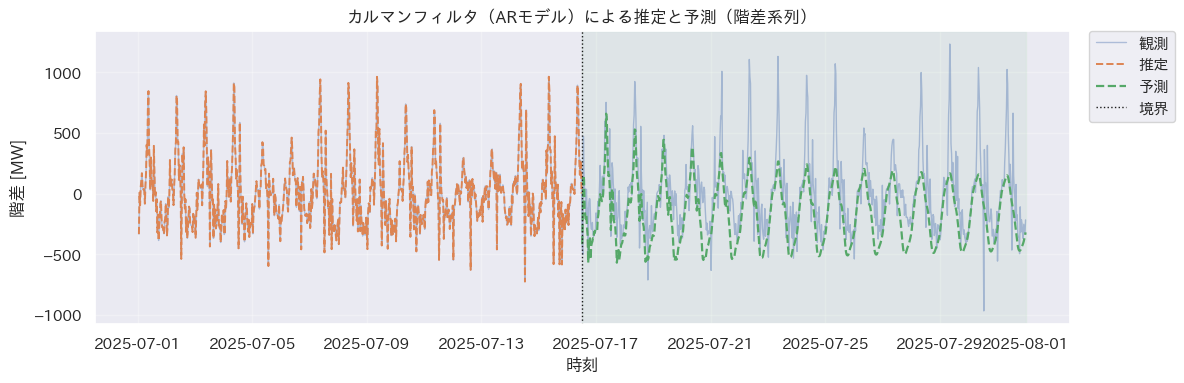

In [24]:
# テストデータ
y_diff_test = df_timeseries['y_fillna_diff'][ntrain:]

# 現在の状態と分散共分散行列を取得
current_state = filtered_state_means[-1]
current_cov = filtered_state_covs[-1]

y_diff_forecast = np.empty(len(y_diff_test))
for idx in range(len(y_diff_test)):
    # filtere_update で 1期先予測を実行(observation=None)
    current_state, current_cov = kf.filter_update(
        current_state,current_cov,observation=None)
    y_diff_forecast[idx] = current_state.dot(H.T)

# 階差系列 （訓練データ区間＋テストデータ区間）
y_diff_orig = df_timeseries['y_fillna_diff'].dropna()
t_diff_all = df_timeseries.loc[y_diff_orig.index, 't']
t_diff_train = df_timeseries.loc[y_diff_train.index, 't']
t_diff_test = df_timeseries.loc[y_diff_test.index, 't']

# プロット
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title('カルマンフィルタ（ARモデル）による推定と予測（階差系列）')
ax.set_xlabel('時刻')
ax.set_ylabel('階差 [MW]')
ax.plot(t_diff_all, y_diff_orig, label='観測', color='C0', alpha=0.4, linewidth=1.0)
ax.plot(t_diff_train, y_diff_filtered_pred, '--', label='推定', color='C1', linewidth=1.4)
ax.plot(t_diff_test, y_diff_forecast, '--', label='予測', color='C2', linewidth=1.6)

t_split = df_timeseries['t'].iloc[ntrain - 1]
ax.axvline(t_split, color='k', linestyle=':', linewidth=1.0, label='境界')
ax.axvspan(df_timeseries['t'].iloc[ntrain], df_timeseries['t'].iloc[-1], color='C2', alpha=0.08)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 原系列 $y_n$ との比較

階差系列の予測 $\widehat{\Delta y_n}$ を累積加算し、その結果に初期実測値 $y_0$を加えて原系列と比較する。

$\hat{y}_n = y_0 + \sum_n \widehat{\Delta y_n}$

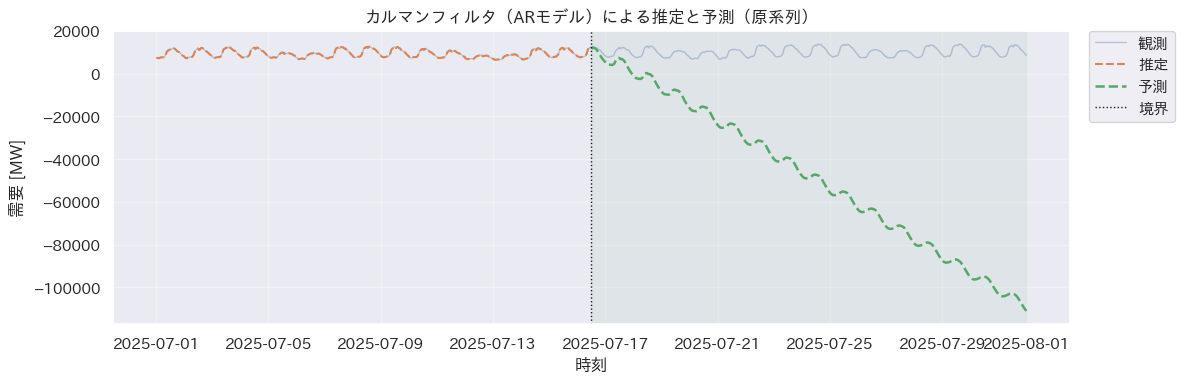

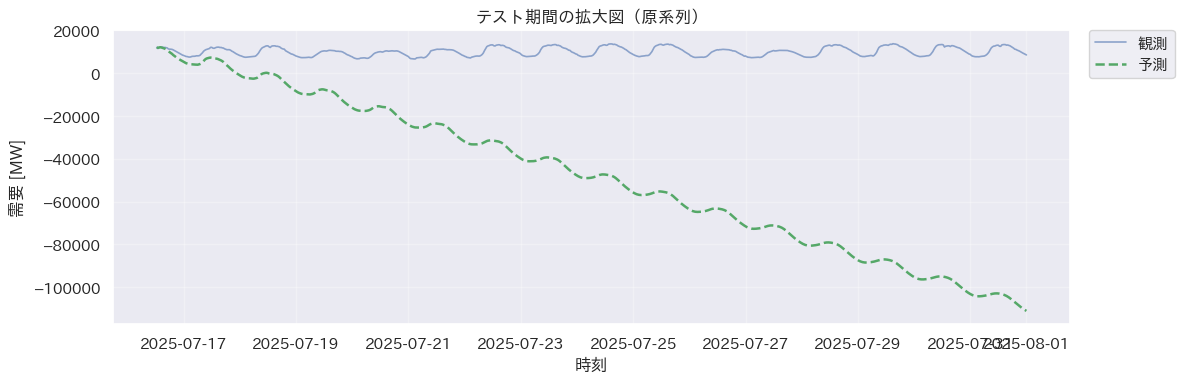

In [25]:
# 原系列 （訓練データ区間＋テストデータ区間）
y_orig = df_timeseries['y_fillna']
t_all = df_timeseries['t']

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title('カルマンフィルタ（ARモデル）による推定と予測（原系列）')
ax.set_xlabel('時刻')
ax.set_ylabel('需要 [MW]')
ax.plot(t_all, y_orig, label='観測', color='C0', alpha=0.35, linewidth=1.0)

# 推定値の先頭に観測の初期値を追加して累積加算
y0 = y_orig.iloc[0]
y_filtered_pred = np.insert(y_diff_filtered_pred, 0, y0).cumsum()
t_train = t_all.iloc[:ntrain]
ax.plot(t_train, y_filtered_pred, '--', label='推定', color='C1', linewidth=1.5)

# 予測値の先頭に推定値の最終値を追加して累積加算
y_filtered_forecast = np.insert(y_diff_forecast, 0, y_filtered_pred[-1]).cumsum()
t_forecast = t_all.iloc[ntrain - 1:ntrain + ntest]
ax.plot(t_forecast, y_filtered_forecast, '--', label='予測', color='C2', linewidth=1.8)

t_split = t_all.iloc[ntrain - 1]
ax.axvline(t_split, color='k', linestyle=':', linewidth=1.0, label='境界')
ax.axvspan(t_all.iloc[ntrain], t_all.iloc[-1], color='C2', alpha=0.08)

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# テスト期間の拡大図（原系列）
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title('テスト期間の拡大図（原系列）')
ax.set_xlabel('時刻')
ax.set_ylabel('需要 [MW]')

t_test = t_all.iloc[ntrain:ntrain + ntest]
y_test = y_orig.iloc[ntrain:ntrain + ntest]
y_pred_test = y_filtered_forecast[1:ntest + 1]

ax.plot(t_test, y_test, label='観測', color='C0', alpha=0.6, linewidth=1.2)
ax.plot(t_test, y_pred_test, '--', label='予測', color='C2', linewidth=1.8)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [26]:
# 予測精度の評価（テスト期間）
y_true = y_orig.iloc[ntrain:ntrain + ntest].to_numpy()
y_pred = y_filtered_forecast[1:ntest + 1]

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
denom = np.where(y_true == 0, np.nan, y_true)
mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

print('評価（原系列, テスト期間）')
print('MAE  = {:.3f} MW'.format(mae))
print('RMSE = {:.3f} MW'.format(rmse))
print('MAPE = {:.2f} %'.format(mape))

評価（原系列, テスト期間）
MAE  = 57984.513 MW
RMSE = 67945.276 MW
MAPE = 585.28 %
